# Rabi splitting of coupled harmonic oscillators

Here, we demonstrate coupling the simple harmonic oscillator (SHO) driver with the `maxwelllink.SingleModeSimulation` electromagnetic solver. By resonantly coupling one classical cavity mode to a SHO, we aim to monitor the cavity coordinate and study the expected Rabi splitting in the frequency domain.

## 1. Defining Molecule

We first create a `Molecule` instance using the non-socket mode, i.e., we directly initialize the SHO within the `Molecule` class:

In [ ]:
import numpy as np
import maxwelllink as mxl

frequency_au = 0.242
mu0 = 187

molecule = mxl.Molecule(
    driver="sho",
    driver_kwargs={
        "omega": frequency_au,
        "mu0": mu0,
        "orientation": 2,
        "p_initial": 1e-2,
    }
)

## 2. Defining the single mode cavity

Then, we create a `SingleModeSimulation` instance which defines the parameters for a single harmonic oscillator. The pre-defined `molecule` is also attached to this class for coupled light-matter simulations.

This single-mode cavity obeys the following equations of motion:

$$
\ddot{q}_{\rm c} = -\omega_{\rm c}^{2}\, q_c - \varepsilon \mu - \gamma_c\, p_{\rm c} + D(t),
$$

where the effective electric field of this cavity mode is

$$
E(t) = -\varepsilon q_{\rm c}(t) - \frac{\varepsilon^2}{\omega_{\rm c}^2}\mu(t).
$$

Here, $\varepsilon = \frac{\omega_{\rm c}}{\sqrt{\epsilon_0 V}}$ is the **coupling strength**. All quantities are in **atomic units**. Dipole self-energy is included in the calculation of the effective electric field $E(t)$. The molecular dipole moment is calculated as $\mu=\mu_0 q_{\rm{SHO}}$.


In [2]:

coupling_strength = 1e-5
dt_au = 1e-1
damping_au = 0e-4
total_steps = 40960

sim = mxl.SingleModeSimulation(
    molecules=[molecule],
    frequency_au=frequency_au,
    coupling_strength=coupling_strength,
    damping_au=damping_au,
    coupling_axis="z",
    drive=0.0,
    dt_au=dt_au,
    qc_initial=[0, 0, 0.0],
    record_history=True,
    # including dipole self-energy term for SHO model
    include_dse=True,
)

print(
    f"Configured SingleModeSimulation with omega_c = {frequency_au:.3f} a.u. "
    f"and g = {coupling_strength:.3f} a.u."
)

sim.run(steps=total_steps)

Configured SingleModeSimulation with omega_c = 0.242 a.u. and g = 0.000 a.u.
[SingleModeCavity] Completed 1000/40960 [2.4%] steps, time/step: 3.64e-05 seconds, remaining time: 1.46 seconds.
[SingleModeCavity] Completed 2000/40960 [4.9%] steps, time/step: 3.51e-05 seconds, remaining time: 1.39 seconds.
[SingleModeCavity] Completed 3000/40960 [7.3%] steps, time/step: 3.54e-05 seconds, remaining time: 1.35 seconds.
[SingleModeCavity] Completed 4000/40960 [9.8%] steps, time/step: 4.01e-05 seconds, remaining time: 1.36 seconds.
[SingleModeCavity] Completed 5000/40960 [12.2%] steps, time/step: 3.67e-05 seconds, remaining time: 1.32 seconds.
[SingleModeCavity] Completed 6000/40960 [14.6%] steps, time/step: 3.71e-05 seconds, remaining time: 1.29 seconds.
[SingleModeCavity] Completed 7000/40960 [17.1%] steps, time/step: 4.30e-05 seconds, remaining time: 1.28 seconds.
[SingleModeCavity] Completed 8000/40960 [19.5%] steps, time/step: 3.44e-05 seconds, remaining time: 1.23 seconds.
[SingleModeCavi

## 3. Retrieve simulation observables

After the simulation, we can retrieve the SHO trajectory from `molecule.extra` together with the cavity coordinate `q_c(t)` stored directly by `SingleModeSimulation`.

In [3]:
q_sho_au = molecule.extra["q_au"]
tls_time_au = molecule.extra["time_au"]

qc_history = np.array(sim.qc_history)[:, 2]  # z-component
energy_history = np.array(sim.energy_history)
time_history = np.array(sim.time_history)

print(
    f"Collected {q_sho_au.size} SHO samples and {qc_history.size} cavity samples."
)

Collected 40960 SHO samples and 40960 cavity samples.


## 4. Inspect time-domain Rabi oscillations

Because the SHO is at resonance with the classical cavity mode, Rabi oscillations can be observed for this coupled system.



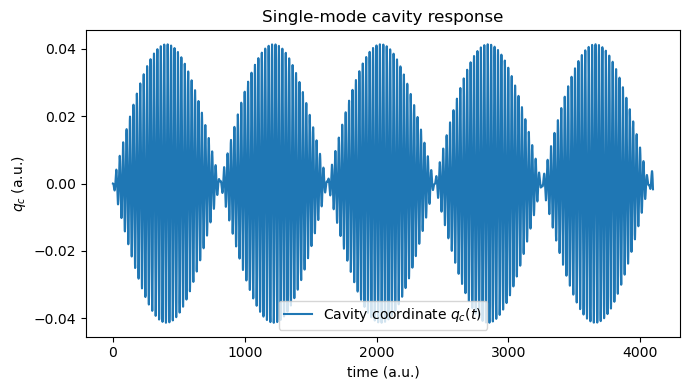

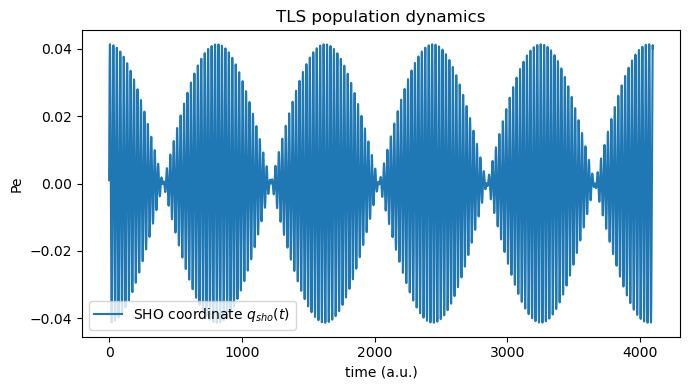

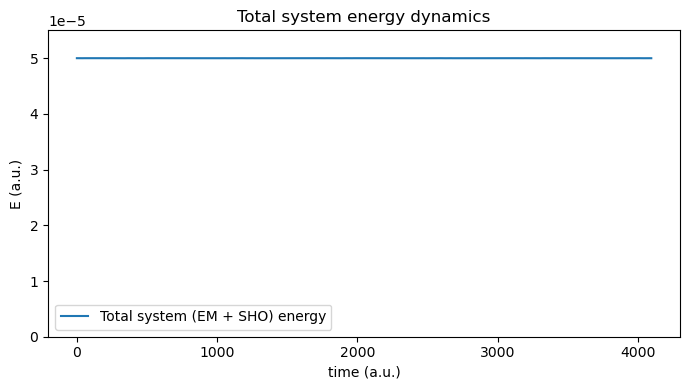

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(time_history, qc_history, label="Cavity coordinate $q_c(t)$")
plt.xlabel("time (a.u.)")
plt.ylabel("$q_c$ (a.u.)")
plt.title("Single-mode cavity response")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(tls_time_au, q_sho_au, label="SHO coordinate $q_{sho}(t)$")
plt.xlabel("time (a.u.)")
plt.ylabel("Pe")
plt.title("TLS population dynamics")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(tls_time_au, energy_history, label="Total system (EM + SHO) energy")
plt.xlabel("time (a.u.)")
plt.ylabel("E (a.u.)")
plt.ylim(0, max(energy_history)*1.1)
plt.title("Total system energy dynamics")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Fourier analysis of the cavity coordinate

For this model, the cavity is coupled to a single SHO with dipole $\mu=\mu_{0}\,q$. Substituting the effective field $E(t)=-\varepsilon q_{c}-(\varepsilon^{2}/\omega_{c}^{2})\mu$ into the SHO equation $\ddot q=-\omega_{0}^{2} q+\mu_{0} E$ together with the cavity equation $\ddot q_{c}=-\omega_{c}^{2} q_{c}-\varepsilon\mu$, we obtain a pair of linearly coupled oscillators

$$
\begin{pmatrix}\ddot q\\ \ddot q_{c}\end{pmatrix}
=-\underbrace{\begin{pmatrix}\omega_{0}^{2}+g_{0}^{2}/\omega_{c}^{2} & g_{0}\\ g_{0} & \omega_{c}^{2}\end{pmatrix}}_{K}\begin{pmatrix}q\\ q_{c}\end{pmatrix},\qquad g_{0}\equiv\varepsilon\mu_{0}.
$$

The dipole self-energy contributes the diagonal shift $g_{0}^{2}/\omega_{c}^{2}$ to the matter frequency. Diagonalizing $K$ yields the **exact** polariton eigenfrequencies

$$
\Omega_{\pm}^{2}=\tfrac{1}{2}\!\left(\omega_{0}^{2}+\omega_{c}^{2}+\tfrac{g_{0}^{2}}{\omega_{c}^{2}}\right)\pm\tfrac{1}{2}\sqrt{\!\left(\omega_{0}^{2}-\omega_{c}^{2}+\tfrac{g_{0}^{2}}{\omega_{c}^{2}}\right)^{2}+4 g_{0}^{2}},
$$

so the analytical Rabi splitting is $\Omega_{\rm Rabi}=\Omega_{+}-\Omega_{-}$. At resonance ($\omega_{0}=\omega_{c}\equiv\omega$) this simplifies to

$$
\Omega_{\pm}^{2}=\omega^{2}+\frac{g_{0}^{2}}{2\omega^{2}}\pm\frac{g_{0}}{2\omega^{2}}\sqrt{g_{0}^{2}+4\omega^{4}}.
$$

We compare this analytical prediction to the numerical Rabi splitting obtained by Fourier transforming the cavity-coordinate dynamics.

In [ ]:
signal = qc_history - np.mean(qc_history)
if signal.size == 0:
    raise RuntimeError("No cavity data recorded; ensure the simulation was executed above.")

dt_sim = np.mean(np.diff(time_history)) if time_history.size > 1 else dt_au
fft_vals = np.fft.rfft(signal)
freqs = np.fft.rfftfreq(signal.size, d=dt_sim) * 2.0 * np.pi
spectrum = np.abs(fft_vals)

# analytical polariton eigenfrequencies of the two coupled HOs (with DSE)
g0 = coupling_strength * mu0
omega0_sq = frequency_au**2
omegac_sq = frequency_au**2
dse_shift = g0**2 / omegac_sq  # diagonal frequency-squared shift on the matter

half_trace = 0.5 * (omega0_sq + omegac_sq + dse_shift)
half_disc = 0.5 * np.sqrt((omega0_sq - omegac_sq + dse_shift)**2 + 4.0 * g0**2)

omega_minus = np.sqrt(half_trace - half_disc)
omega_plus  = np.sqrt(half_trace + half_disc)
rabi_splitting = omega_plus - omega_minus

expected_peaks = np.array([omega_minus, omega_plus])

print(f"g_0 = epsilon * mu0 = {g0:.3e} a.u.")
print(f"Analytical lower / upper polariton: {omega_minus:.6f} / {omega_plus:.6f} a.u.")
print(f"Analytical Rabi splitting Omega_+ - Omega_- = {rabi_splitting:.6e} a.u.")

plt.figure(figsize=(7, 4))
plt.plot(freqs, spectrum, label="|FFT(q_c)|")
for idx, freq in enumerate(expected_peaks):
    label = r"$\Omega_\pm$ (analytical)" if idx == 0 else None
    plt.axvline(freq, color="red", linestyle="--", label=label)
plt.xlabel("frequency (a.u.)")
plt.xlim(frequency_au*0.5, frequency_au*1.5)
plt.ylabel("spectral amplitude")
plt.title("Cavity-mode spectrum")
plt.legend()
plt.tight_layout()
plt.show()